In [54]:
from src.serializers import SessionOutput, SequenceOutput
from src.data_loading.from_files import load_all_sessions_from_raw_data
from src.data_loading.from_server import load_sessions_from_student, load_all_sessions
from dotenv import load_dotenv
from src.utils import compare_sequences
import os
import json
import time
import datetime

load_dotenv()
url = os.getenv("SERVER_URL")
auth_token = os.getenv("BASIC_AUTH")


In [2]:
all_sessions = load_all_sessions(url, auth_token)

all_sequences_list = []

for student_id, sessions in all_sessions.items():
    for session in sessions:
        all_sequences_list.extend(session.sequences)
        
print(len(all_sequences_list))

Chargement des sessions pour l'étudiant E1 depuis le serveur
S1
S2
S3
Chargement des sessions pour l'étudiant E2 depuis le serveur
S1
S2
S3
S4
Chargement des sessions pour l'étudiant E3 depuis le serveur
S1
S2
S3
S4
Chargement des sessions pour l'étudiant E4 depuis le serveur
S1
Chargement des sessions pour l'étudiant E5 depuis le serveur
S1
S2
Chargement des sessions pour l'étudiant E6 depuis le serveur
Chargement des sessions pour l'étudiant E7 depuis le serveur
S1
S2
S3
S4
Chargement des sessions pour l'étudiant E8 depuis le serveur
S1
S2
S3
S4
57


## Comparaisons avec les données des autres étudiants

On peut s'amuser à comparer les données pour chaque étudiant pour le protocole montée-descente-montée des 4 étages de l'esiee.

Mon `studentId` est E3.

On peut donc faire des analyses simples de la distribution des données, avec des diagrammes en moustache


In [3]:
sessions_mdm = [all_sessions["E1"][0],all_sessions["E2"][0], all_sessions["E3"][1], all_sessions["E5"][1], all_sessions["E7"][0], all_sessions["E8"][0]]
compare_sequences([session.sequences[2] for session in sessions_mdm], channel="RESP_THORAX")

On constate que la distribution des valeurs pour la respiration est étrange pour certains cas (le canal a des amplitudes de valeurs bien inférieures à ce qu'elles devraient être)

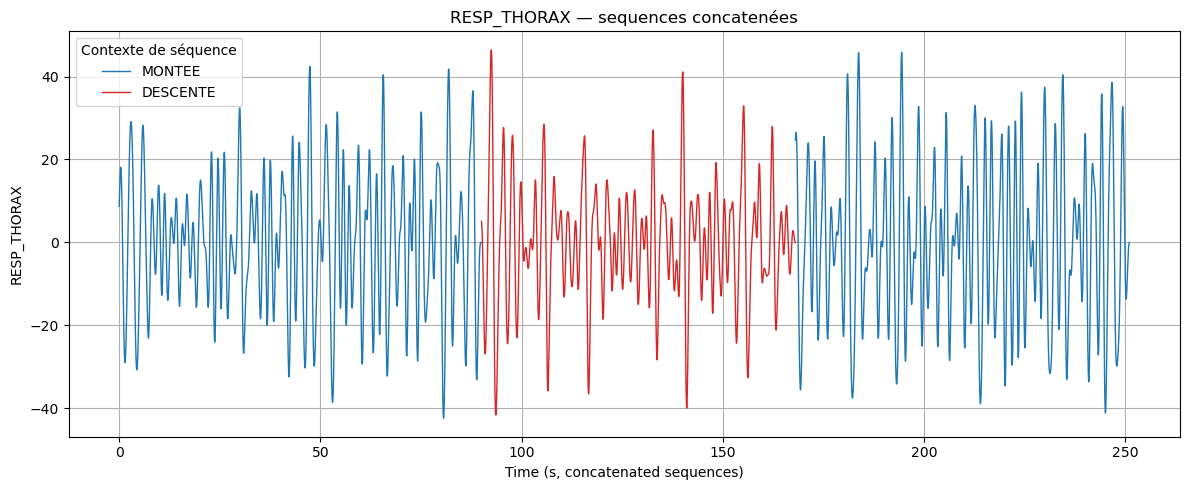

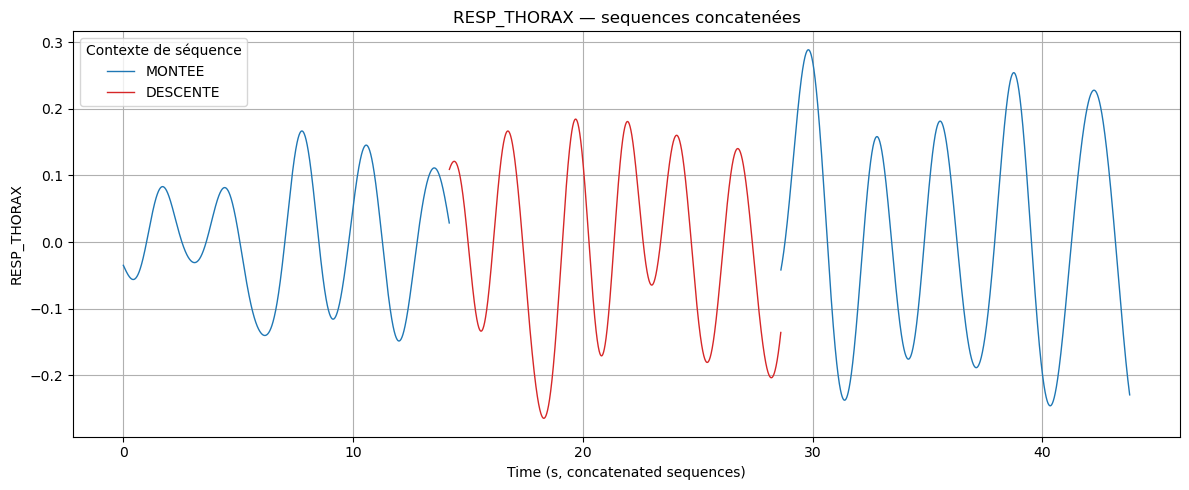

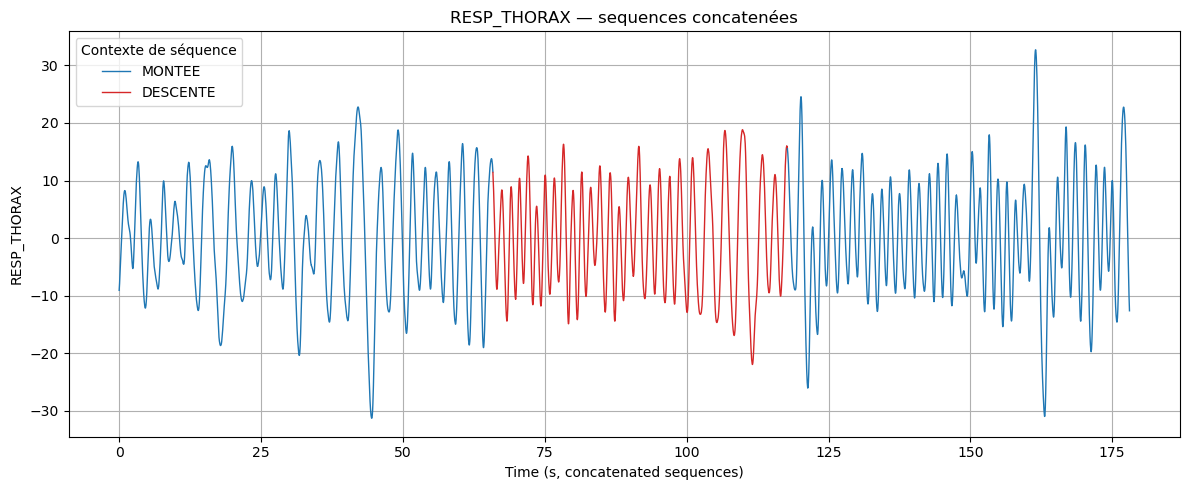

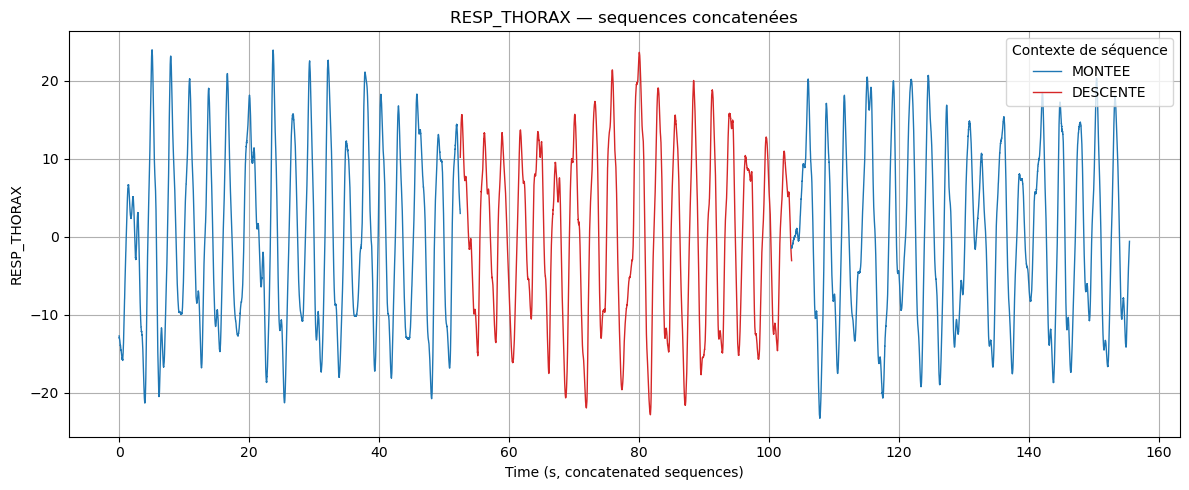

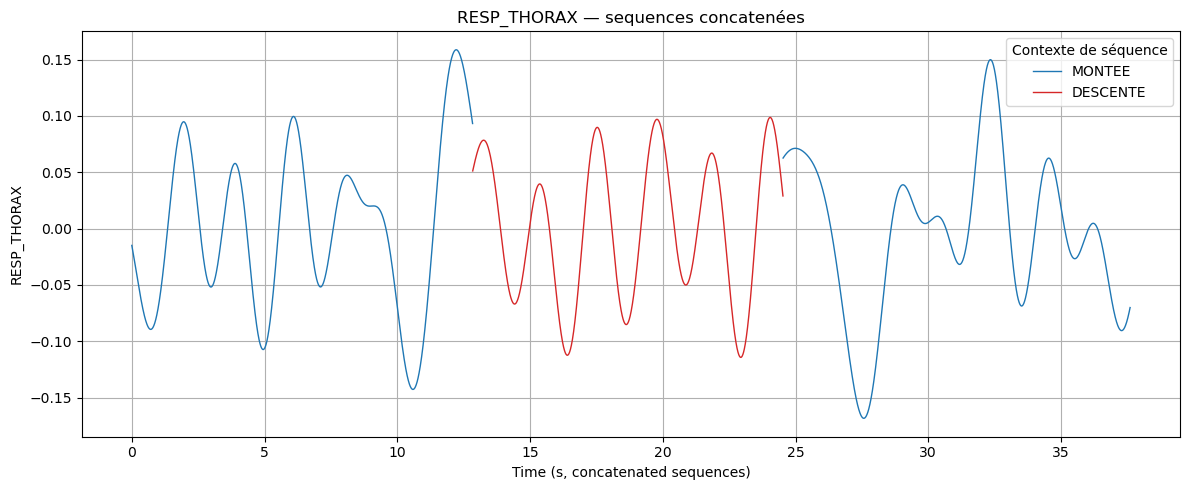

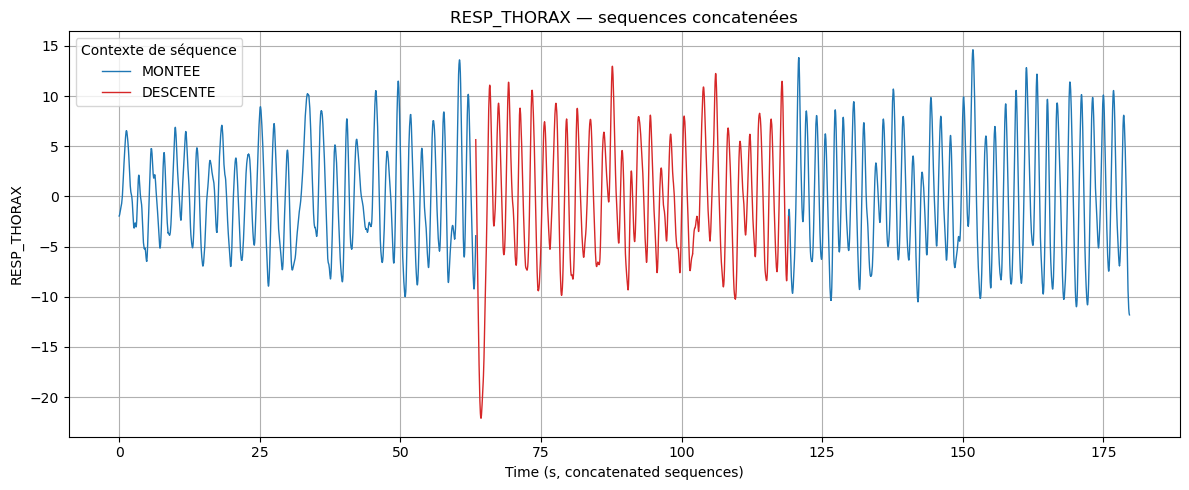

In [4]:
for session in sessions_mdm:
    session.plot("RESP_THORAX", timestamp=True)

On constate que pour les étudiants où l'amplitude des valeurs est plus faible, on a beaucoup moins de respirations, et la session dure bien moins longtemps (moins de 40 secondes). Les données sont corrompues, donc on supprime ces étudiants des analyses que l'on fait après.

In [57]:
def analyse_montee(sequence_montee : SequenceOutput):
    prominence = 10
    sequence_montee.simple_line_plot_with_peaks("RESP_THORAX", prominence=prominence, timestamp=True).show()
    n_peaks = sequence_montee.get_number_of_peaks("RESP_THORAX", prominence=prominence)
    duration = (sequence_montee.dataframe["timestamp"].iloc[-1] - sequence_montee.dataframe["timestamp"].iloc[0]).total_seconds()
    avg_amplitude = sequence_montee.dataframe["RESP_THORAX"].std()
    breathing_rate = 60*n_peaks/duration
    return duration, n_peaks, breathing_rate, avg_amplitude

Etudiant E1 - Montee 1: Amplitude moyenne 10.18%
28 respirations en 65.86 secondes (25.51 respirations/minute)
-------
Etudiant E1 - Montee 2: Amplitude moyenne 10.17%
37 respirations en 60.28 secondes (36.83 respirations/minute)
Entre la première montée (frais) et la deuxième montée (fatigué), la fréquence respiratoire a augmenté de 44.35%
L'amplitude moyenne a augmenté de -0.10%


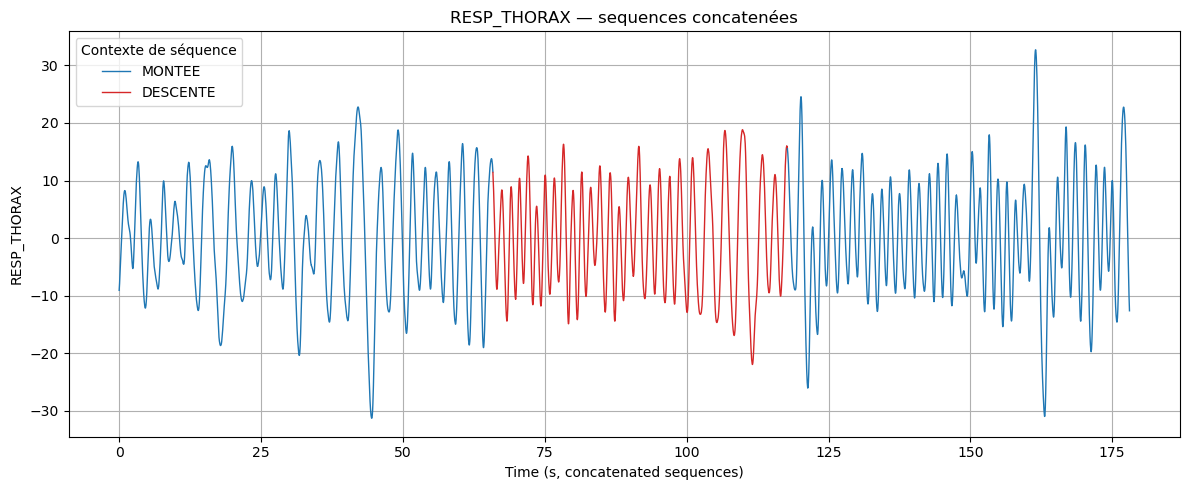

In [ ]:
sessions_mdm = [all_sessions["E1"][0], all_sessions["E3"][1], all_sessions["E5"][1], all_sessions["E8"][0]]

def analyse_mdm(session, student_id):
    prominence = 10
    session.plot("RESP_THORAX", timestamp=True)
    montee_1 = session.sequences[0]
    montee_2 = session.sequences[2]
    duration_1, n_peaks_1, breathing_rate_1, avg_amplitude_1 = analyse_montee(montee_1)
    duration_2, n_peaks_2, breathing_rate_2, avg_amplitude_2 = analyse_montee(montee_2)
    
    print(f"Etudiant {student_id} - Montee 1: Amplitude moyenne {avg_amplitude_1:.2f}%")
    print(f"{n_peaks_1} respirations en {duration_1:.2f} secondes ({breathing_rate_1:.2f} respirations/minute)")
    print("-------")
    print(f"Etudiant {student_id} - Montee 2: Amplitude moyenne {avg_amplitude_2:.2f}%")
    print(f"{n_peaks_2} respirations en {duration_2:.2f} secondes ({breathing_rate_2:.2f} respirations/minute)")
    
    print(f"Entre la première montée (frais) et la deuxième montée (fatigué), la fréquence respiratoire a augmenté de {(breathing_rate_2 - breathing_rate_1)/breathing_rate_1*100:.2f}%")
    print(f"L'amplitude moyenne a augmenté de {(avg_amplitude_2 - avg_amplitude_1)/avg_amplitude_1*100:.2f}%")
    

analyse_mdm(sessions_mdm[1], "E2")

## Identification des marches lors des montées et descentes

On peut identifier les marches de l'escalier lors des montées et descentes, il est même possible d'identifier les paliers.

In [48]:
session_mdm_e3 = sessions_mdm[1]
session_mdm_e3.sequences[0].local_average_plot(channel="ACC_VERTICAL", window_size_seconds=0.5)

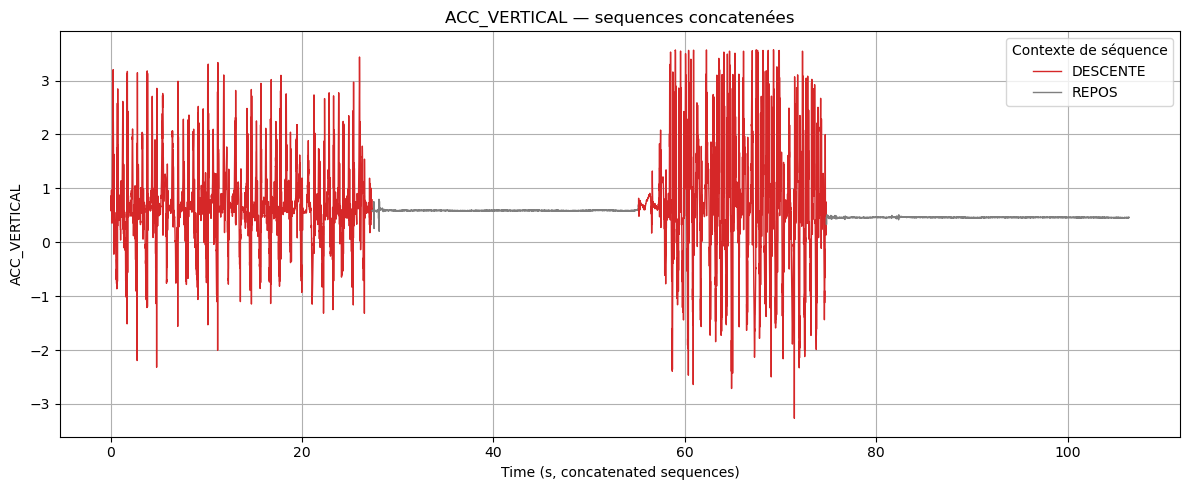

In [66]:
session_4 = all_sessions["E3"][3]
session_4.plot("ACC_VERTICAL", timestamp=True);

In [ ]:
session_4.sequences[0].local_average_plot(channel="ACC_VERTICAL", window_size_seconds=0.5)

In [76]:
session_4.sequences[2].local_average_plot(channel="ACC_VERTICAL", window_size_seconds=0.5)

## Analyse de la respiration en fonction de l'activité avant la montée

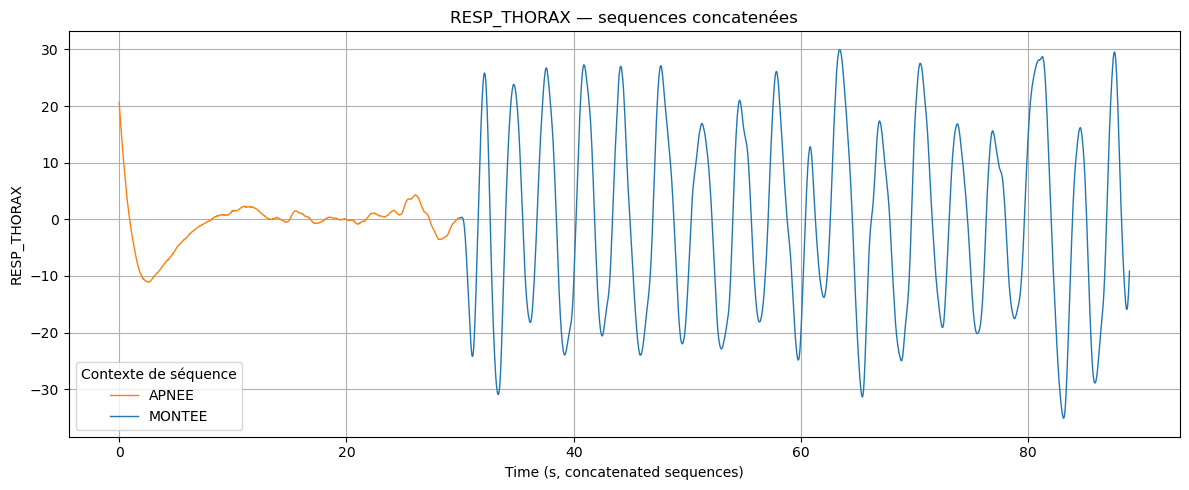

In [60]:
session_3 = all_sessions["E3"][2]
session_3.plot("RESP_THORAX", timestamp=True);

In [64]:
duration, n_peaks, breathing_rate, avg_amplitude = analyse_montee(session_3.sequences[1])
print(f"Etudiant {student_id} - Montee après apnée : Amplitude moyenne {avg_amplitude:.2f}%")
print(f"{n_peaks} respirations en {duration:.2f} secondes ({breathing_rate:.2f} respirations/minute)")


Etudiant E8 - Montee après apnée : Amplitude moyenne 16.82%
21 respirations en 58.90 secondes (21.39 respirations/minute)
